In [24]:
# Local/WSL workflow: ConvNeXt experiment notebook.


# ConvNeXt Tiny transfer learning on ROI mammogram data

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

if gpus:
    mixed_precision.set_global_policy("mixed_float16")

print("TF version:", tf.__version__)
print("GPU:", gpus)
print("Mixed precision policy:", mixed_precision.global_policy())

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import numpy as np

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [26]:
import os
import random
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)


In [27]:
def count_files_by_class(root_dir):
    counts = {}
    for class_name in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        counts[class_name] = sum(
            1
            for file_name in os.listdir(class_dir)
            if file_name.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
        )
    return counts


def summarize_labels(ds, class_names):
    counts = Counter()
    for _, labels in ds:
        labels = labels.numpy().astype("int32").reshape(-1)
        counts.update(labels.tolist())
    return {class_names[idx]: counts.get(idx, 0) for idx in range(len(class_names))}


In [28]:
# Dataset path is configured in the next cell.


In [29]:
data_dir = "/mnt/e/DDSM/ROI"
assert os.path.exists(data_dir), f"Dataset path not found: {data_dir}"

In [30]:
raw_class_counts = count_files_by_class(data_dir)
print("Raw file counts by class:", raw_class_counts)


Raw file counts by class: {'ROI_Benign': 1402, 'ROI_Cancer': 1428}


Quick check: inspect one training batch after the dataset cell runs.

Diagnostics: verify split sizes, class balance, and one sample batch before training.

In [31]:
img_size = (224, 224)
batch_size = 16
seed = 123
AUTOTUNE = tf.data.AUTOTUNE

os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
keras.utils.set_random_seed(seed)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
)

class_names = train_ds.class_names
print("Classes:", class_names)
print(f"Positive class for AUC/ROC: {class_names[1]}")

temp_card = tf.data.experimental.cardinality(temp_ds).numpy()
if temp_card < 2:
    raise ValueError(f"Validation split is too small: only {temp_card} batch(es). Reduce batch_size or use more data.")

val_batches = max(1, temp_card // 2)
test_batches = temp_card - val_batches
if test_batches == 0:
    raise ValueError("Test split is empty. Reduce batch_size or use more data.")

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

def prepare(ds, shuffle=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=seed, reshuffle_each_iteration=True)
    return ds.prefetch(AUTOTUNE)

train_ds_prep = prepare(train_ds, shuffle=True)
val_ds_prep = prepare(val_ds)
test_ds_prep = prepare(test_ds)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

train_label_counts = summarize_labels(train_ds, class_names)
val_label_counts = summarize_labels(val_ds, class_names)
test_label_counts = summarize_labels(test_ds, class_names)

print("Train label counts:", train_label_counts)
print("Validation label counts:", val_label_counts)
print("Test label counts:", test_label_counts)


Found 2830 files belonging to 2 classes.
Using 2264 files for training.
Found 2830 files belonging to 2 classes.
Using 566 files for validation.
Classes: ['ROI_Benign', 'ROI_Cancer']
Positive class for AUC/ROC: ROI_Cancer
Train batches: 142
Validation batches: 18
Test batches: 18


2026-03-11 11:42:21.350649: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Train label counts: {'ROI_Benign': 1123, 'ROI_Cancer': 1141}
Validation label counts: {'ROI_Benign': 146, 'ROI_Cancer': 142}
Test label counts: {'ROI_Benign': 143, 'ROI_Cancer': 135}


2026-03-11 11:42:24.300763: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [32]:
for images, labels in train_ds.take(1):
    print("image batch:", images.shape)
    print("label batch:", labels.shape)
    print("labels:", labels[:8].numpy().reshape(-1))


image batch: (16, 224, 224, 3)
label batch: (16, 1)
labels: [0. 0. 0. 0. 1. 1. 0. 1.]


In [33]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.10),
    keras.layers.RandomZoom(0.20),
    keras.layers.RandomTranslation(0.05, 0.05),
    keras.layers.RandomContrast(0.20),
], name="data_augmentation")


In [34]:
backbone = keras.applications.ConvNeXtTiny(
    include_top=False,
    include_preprocessing=False,
    weights="imagenet",
    input_shape=img_size + (3,),
    pooling="avg",
)

preprocessing = keras.Sequential(
    [keras.layers.Rescaling(1.0 / 255)],
    name="preprocessing"
)

inputs = keras.Input(shape=img_size + (3,))
x = preprocessing(inputs)
x = data_augmentation(x)
x = backbone(x, training=False)
x = keras.layers.Dense(256, activation="gelu")(x)
x = keras.layers.Dropout(0.4)(x)
outputs = keras.layers.Dense(1, activation="sigmoid", dtype="float32", name="cancer_prob")(x)

model = keras.Model(inputs, outputs)
print("Backbone type:", type(backbone).__name__)
print("Model output shape:", model.output_shape)
model.summary()


Backbone type: Functional
Model output shape: (None, 1)


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 768)            │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cancer_prob (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,017,249 (106.88 MB)

 Trainable params: 28,017,249 (106.88 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
backbone.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

stage1_trainable_weights = len(model.trainable_weights)
print("Stage 1 monitor: val_auc")
print("Stage 1 trainable weights:", stage1_trainable_weights)

stage1_ckpt = "/mnt/e/SW_training_outputs/checkpoints/best_convnext_stage1.keras"
cb1 = [
    keras.callbacks.ModelCheckpoint(
        stage1_ckpt,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

history1 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=10,
    callbacks=cb1,
    verbose=1,
)


Stage 1 monitor: val_auc
Stage 1 trainable weights: 4
Epoch 1/10


2026-03-11 11:42:44.204747: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - acc: 0.5351 - auc: 0.5522 - loss: 0.7622 - precision: 0.5254 - recall: 0.5221
Epoch 1: val_auc improved from None to 0.66312, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_stage1.keras

Epoch 1: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_stage1.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 40s 132ms/step - acc: 0.5548 - auc: 0.5753 - loss: 0.7445 - precision: 0.5572 - recall: 0.5679 - val_acc: 0.5972 - val_auc: 0.6631 - val_loss: 0.6590 - val_precision: 0.6587 - val_recall: 0.5321
Epoch 2/10


2026-03-11 11:43:10.996586: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - acc: 0.5751 - auc: 0.5956 - loss: 0.7256 - precision: 0.5918 - recall: 0.5691
Epoch 2: val_auc improved from 0.66312 to 0.72549, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_stage1.keras

Epoch 2: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_stage1.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - acc: 0.5883 - auc: 0.6170 - loss: 0.7040 - precision: 0.5972 - recall: 0.5627 - val_acc: 0.7014 - val_auc: 0.7255 - val_loss: 0.6129 - val_precision: 0.7185 - val_recall: 0.6690
Epoch 3/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - acc: 0.5923 - auc: 0.6338 - loss: 0.6837 - precision: 0.5956 - recall: 0.5765
Epoch 3: val_auc did not improve from 0.72549
142/142 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - acc: 0.5958 - auc: 0.6349 - loss: 0.6831 - precision: 0.6002 - recall: 0.5933 - val_acc: 0.6250 - val_auc: 0.6882 - val_loss: 0.6394 - val_precision: 0.6273 - val_recall: 0.6779
Epoch 4/10
142/142

In [36]:
# Stage 2: unfreeze a larger tail of ConvNeXt for domain adaptation.
backbone.trainable = True
num_layers_to_unfreeze = 90

for layer in backbone.layers:
    layer.trainable = False

fine_tune_layers = backbone.layers[-num_layers_to_unfreeze:]
for layer in fine_tune_layers:
    layer.trainable = True

fine_tune_layer_names = [layer.name for layer in fine_tune_layers]
stage2_trainable_weights = len(model.trainable_weights)
print("Stage 2 monitor: val_auc")
print("ConvNeXt backbone layers:", len(backbone.layers))
print("Stage 1 trainable weights:", stage1_trainable_weights)
print("Stage 2 trainable weights:", stage2_trainable_weights)
print("Additional trainable weights after unfreezing:", stage2_trainable_weights - stage1_trainable_weights)
print("Unfrozen last layers:", fine_tune_layer_names)

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4,
    ),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

ckpt_path = "/mnt/e/SW_training_outputs/checkpoints/best_convnext_model.keras"
cb2 = [
    keras.callbacks.ModelCheckpoint(
        ckpt_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

history2 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=50,
    initial_epoch=len(history1.history["loss"]),
    callbacks=cb2,
    verbose=1,
)


Stage 2 monitor: val_auc
ConvNeXt backbone layers: 133
Stage 1 trainable weights: 4
Stage 2 trainable weights: 123
Additional trainable weights after unfreezing: 119
Unfrozen last layers: ['convnext_tiny_stage_1_block_2_layer_scale', 'convnext_tiny_stage_1_block_2_identity', 'convnext_tiny_downsampling_block_1', 'convnext_tiny_stage_2_block_0_depthwise_conv', 'convnext_tiny_stage_2_block_0_layernorm', 'convnext_tiny_stage_2_block_0_pointwise_conv_1', 'convnext_tiny_stage_2_block_0_gelu', 'convnext_tiny_stage_2_block_0_pointwise_conv_2', 'convnext_tiny_stage_2_block_0_layer_scale', 'convnext_tiny_stage_2_block_0_identity', 'convnext_tiny_stage_2_block_1_depthwise_conv', 'convnext_tiny_stage_2_block_1_layernorm', 'convnext_tiny_stage_2_block_1_pointwise_conv_1', 'convnext_tiny_stage_2_block_1_gelu', 'convnext_tiny_stage_2_block_1_pointwise_conv_2', 'convnext_tiny_stage_2_block_1_layer_scale', 'convnext_tiny_stage_2_block_1_identity', 'convnext_tiny_stage_2_block_2_depthwise_conv', 'convn

2026-03-11 11:45:05.533069: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - acc: 0.6510 - auc: 0.6894 - loss: 0.6385 - precision: 0.6617 - recall: 0.6139
Epoch 9: val_auc improved from None to 0.71203, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_model.keras

Epoch 9: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 87s 441ms/step - acc: 0.6564 - auc: 0.7017 - loss: 0.6289 - precision: 0.6673 - recall: 0.6345 - val_acc: 0.6597 - val_auc: 0.7120 - val_loss: 0.6222 - val_precision: 0.7368 - val_recall: 0.4895
Epoch 10/50


2026-03-11 11:46:24.329694: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:293: Filling up shuffle buffer (this may take a while): 50 of 1000
2026-03-11 11:46:41.630805: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - acc: 0.6560 - auc: 0.7044 - loss: 0.6252 - precision: 0.6714 - recall: 0.6289
Epoch 10: val_auc improved from 0.71203 to 0.75210, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_model.keras

Epoch 10: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 96s 473ms/step - acc: 0.6586 - auc: 0.7109 - loss: 0.6219 - precision: 0.6720 - recall: 0.6301 - val_acc: 0.7118 - val_auc: 0.7521 - val_loss: 0.5809 - val_precision: 0.7521 - val_recall: 0.6197
Epoch 11/50


...

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - acc: 0.7462 - auc: 0.8139 - loss: 0.5230 - precision: 0.7948 - recall: 0.6724
Epoch 17: val_auc improved from 0.76021 to 0.76891, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_model.keras

Epoch 17: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 75s 366ms/step - acc: 0.7226 - auc: 0.7995 - loss: 0.5371 - precision: 0.7615 - recall: 0.6547 - val_acc: 0.7118 - val_auc: 0.7689 - val_loss: 0.5654 - val_precision: 0.7946 - val_recall: 0.5973
Epoch 18/50


2026-03-11 11:54:41.429027: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:293: Filling up shuffle buffer (this may take a while): 53 of 1000
2026-03-11 11:54:46.681950: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - acc: 0.7361 - auc: 0.8116 - loss: 0.5231 - precision: 0.7853 - recall: 0.6727
Epoch 18: val_auc did not improve from 0.76891
142/142 ━━━━━━━━━━━━━━━━━━━━ 60s 310ms/step - acc: 0.7337 - auc: 0.8126 - loss: 0.5206 - precision: 0.7695 - recall: 0.6731 - val_acc: 0.6979 - val_auc: 0.7538 - val_loss: 0.5858 - val_precision: 0.7810 - val_recall: 0.5616
Epoch 19/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - acc: 0.7474 - auc: 0.8143 - loss: 0.5131 - precision: 0.7801 - recall: 0.6861
Epoch 19: val_auc improved from 0.76891 to 0.77007, saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_model.keras

Epoch 19: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_convnext_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 53s 367ms/step - acc: 0.7407 - auc: 0.8177 - loss: 0.5137 - precision: 0.7674 - recall: 0.6968 - val_acc: 0.7153 - val_auc: 0.7701 - val_loss: 0.5720 - val_precision: 0.7815 - val_recall: 0.6242
Epoch 20/50


2026-03-11 11:56:34.365553: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:293: Filling up shuffle buffer (this may take a while): 54 of 1000
2026-03-11 11:56:44.484634: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:293: Filling up shuffle buffer (this may take a while): 104 of 1000
2026-03-11 11:56:51.902217: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - acc: 0.7466 - auc: 0.8265 - loss: 0.5068 - precision: 0.7969 - recall: 0.6801
Epoch 20: val_auc did not improve from 0.77007
142/142 ━━━━━━━━━━━━━━━━━━━━ 76s 340ms/step - acc: 0.7465 - auc: 0.8256 - loss: 0.5032 - precision: 0.7878 - recall: 0.6801 - val_acc: 0.6840 - val_auc: 0.7297 - val_loss: 0.6203 - val_precision: 0.8438 - val_recall: 0.5159
Epoch 21/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - acc: 0.7602 - auc: 0.8397 - loss: 0.4891 - precision: 0.8012 - recall: 0.7137
Epoch 21: val_auc did not improve from 0.77007
142/142 ━━━━━━━━━━━━━━━━━━━━ 43s 291ms/step - acc: 0.7496 - auc: 0.8268 - loss: 0.5018 - precision: 0.7847 - recall: 0.6933 - val_acc: 0.6875 - val_auc: 0.7362 - val_loss: 0.5964 - val_precision: 0.7876 - val_recall: 0.5742
Epoch 22/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - acc: 0.7678 - auc: 0.8459 - loss: 0.4816 - precision: 0.8176 - recall: 0.6817
Epoch 22: val_auc did not improve from 0.77007
142/142 ━━━━━━━━━━

In [37]:
print("Backbone trainable:", backbone.trainable)
print("Trainable weights:", len(model.trainable_weights))
print("Unfrozen last layers count:", len(fine_tune_layer_names))
print("Unfrozen last layers:", fine_tune_layer_names)


Backbone trainable: True
Trainable weights: 123
Unfrozen last layers count: 90
Unfrozen last layers: ['convnext_tiny_stage_1_block_2_layer_scale', 'convnext_tiny_stage_1_block_2_identity', 'convnext_tiny_downsampling_block_1', 'convnext_tiny_stage_2_block_0_depthwise_conv', 'convnext_tiny_stage_2_block_0_layernorm', 'convnext_tiny_stage_2_block_0_pointwise_conv_1', 'convnext_tiny_stage_2_block_0_gelu', 'convnext_tiny_stage_2_block_0_pointwise_conv_2', 'convnext_tiny_stage_2_block_0_layer_scale', 'convnext_tiny_stage_2_block_0_identity', 'convnext_tiny_stage_2_block_1_depthwise_conv', 'convnext_tiny_stage_2_block_1_layernorm', 'convnext_tiny_stage_2_block_1_pointwise_conv_1', 'convnext_tiny_stage_2_block_1_gelu', 'convnext_tiny_stage_2_block_1_pointwise_conv_2', 'convnext_tiny_stage_2_block_1_layer_scale', 'convnext_tiny_stage_2_block_1_identity', 'convnext_tiny_stage_2_block_2_depthwise_conv', 'convnext_tiny_stage_2_block_2_layernorm', 'convnext_tiny_stage_2_block_2_pointwise_conv_1', 

In [38]:
best_model = keras.models.load_model(ckpt_path)
best_model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)
print("Loaded best model from:", ckpt_path)
print("Best model output shape:", best_model.output_shape)


Loaded best model from: /mnt/e/SW_training_outputs/checkpoints/best_convnext_model.keras
Best model output shape: (None, 1)


In [39]:
test_metrics = best_model.evaluate(test_ds_prep, return_dict=True)
if not isinstance(test_metrics, dict):
    raise TypeError(
        f"Expected evaluate(..., return_dict=True) to return dict, got {type(test_metrics).__name__}. "
        "Restart the kernel and rerun the notebook from the import cells."
    )
print("Evaluation metrics:", test_metrics)


18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 202ms/step - acc: 0.7302 - auc: 0.7672 - loss: 0.5610 - precision: 0.7928 - recall: 0.6286
Evaluation metrics: {'acc': 0.730215847492218, 'auc': 0.7672359943389893, 'loss': 0.5609709620475769, 'precision': 0.792792797088623, 'recall': 0.6285714507102966}


2026-03-11 12:01:29.803564: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-03-11 12:01:34.856141: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Positive class for ROC/AUC: ROI_Cancer
First 20 test_true: [1 1 0 0 1 1 0 1 1 1 0 1 0 0 1 1 1 0 0 0]
First 20 test_prob: [0.9392 0.7661 0.5795 0.2321 0.5777 0.3488 0.2442 0.21   0.9884 0.9646
 0.4884 0.861  0.2317 0.2392 0.9235 0.3512 0.8534 0.5678 0.8246 0.1815]
Probability range: 0.06409900635480881 0.9883694648742676
Probability mean/std: 0.5066201686859131 0.27021709084510803
Test AUC: 0.7821
Test Accuracy: 0.7266
Confusion Matrix:
 [[112  27]
 [ 49  90]]
Classification Report:
               precision    recall  f1-score   support

  ROI_Benign       0.70      0.81      0.75       139
  ROI_Cancer       0.77      0.65      0.70       139

    accuracy                           0.73       278
   macro avg       0.73      0.73      0.72       278
weighted avg       0.73      0.73      0.72       278



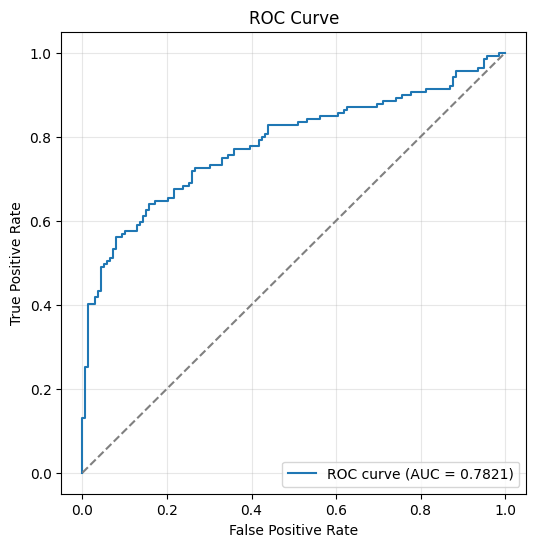

In [40]:
def collect_predictions(ds, model):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pb = model.predict(xb, verbose=0).reshape(-1)
        y_true.append(yb.numpy().reshape(-1))
        y_prob.append(pb)
    return np.concatenate(y_true).astype("int32"), np.concatenate(y_prob)

test_true, test_prob = collect_predictions(test_ds_prep, best_model)
test_pred = (test_prob >= 0.5).astype("int32")

print("Positive class for ROC/AUC:", class_names[1])
print("First 20 test_true:", test_true[:20])
print("First 20 test_prob:", np.round(test_prob[:20], 4))
print("Probability range:", float(test_prob.min()), float(test_prob.max()))
print("Probability mean/std:", float(test_prob.mean()), float(test_prob.std()))

test_fpr, test_tpr, _ = roc_curve(test_true, test_prob)
test_auc = roc_auc_score(test_true, test_prob)
test_acc = accuracy_score(test_true, test_pred)
cm = confusion_matrix(test_true, test_pred)

print(f"Test AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(test_true, test_pred, target_names=class_names))
if test_auc < 0.55:
    print("AUC is below 0.55. Stop tuning ConvNeXt further and run the ResNet50 baseline with the same split.")

plt.figure(figsize=(6, 6))
plt.plot(test_fpr, test_tpr, label=f"ROC curve (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


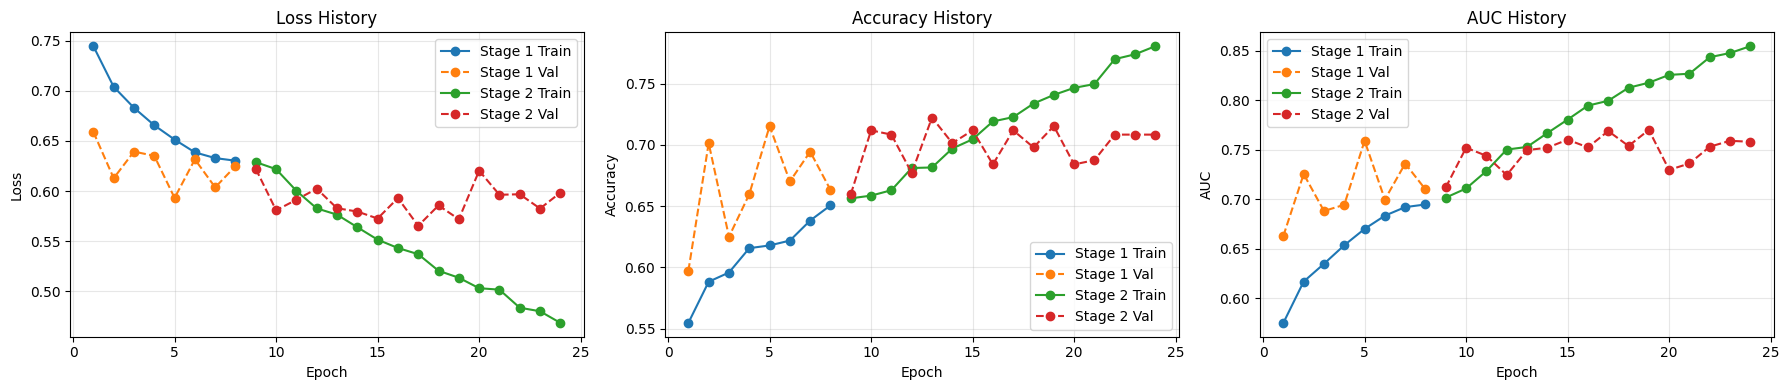

: 

In [ ]:
# Plot Stage 1 and Stage 2 training histories with Stage 2 continuing after Stage 1.
histories_to_plot = []
if 'history1' in globals() and hasattr(history1, 'history'):
    histories_to_plot.append(('Stage 1', history1.history))
if 'history2' in globals() and hasattr(history2, 'history'):
    histories_to_plot.append(('Stage 2', history2.history))

if not histories_to_plot:
    raise ValueError('No training history found. Run the training cells first.')

metrics = [
    ('loss', 'Loss'),
    ('acc', 'Accuracy'),
    ('auc', 'AUC'),
]

stage1_epochs = len(history1.history['loss']) if 'history1' in globals() and hasattr(history1, 'history') else 0

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (metric_key, metric_label) in zip(axes, metrics):
    for stage_name, hist in histories_to_plot:
        num_epochs = len(hist[metric_key]) if metric_key in hist else len(hist.get(f'val_{metric_key}', []))
        if num_epochs == 0:
            continue

        if stage_name == 'Stage 1':
            epochs = range(1, num_epochs + 1)
        else:
            epochs = range(stage1_epochs + 1, stage1_epochs + num_epochs + 1)

        if metric_key in hist:
            ax.plot(epochs, hist[metric_key], marker='o', label=f'{stage_name} Train')
        val_key = f'val_{metric_key}'
        if val_key in hist:
            ax.plot(epochs, hist[val_key], marker='o', linestyle='--', label=f'{stage_name} Val')

    ax.set_title(f'{metric_label} History')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric_label)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()
